# Bayesian Spatial Flow (Origin–Destination) Models

This notebook demonstrates the **cross-sectional** flow models in `bayespecon`:

| Model | Description |
|---|---|
| `SAR_Flow` | Three free ρ parameters — destination, origin, network |
| `SAR_Flow_Separable` | Constrained ρ_w = −ρ_d·ρ_o; exact eigenvalue log-det |

Both are fully Bayesian implementations of the LeSage–Fischer (2008) SAR flow framework.

---

## Background: The SAR Flow Model

Let $y$ be the $N$-vector of observed flows ($N = n^2$ O-D pairs). The model is

$$
y = \rho_d W_d y + \rho_o W_o y + \rho_w W_w y + X\beta + \varepsilon,
\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_N)
$$

where

$$
W_d = I_n \otimes W, \quad W_o = W \otimes I_n, \quad W_w = W \otimes W
$$

capture **destination**, **origin**, and **network** (O-D pair) neighbourhood dependence respectively.

The **reduced form** is

$$
y = (I_N - \rho_d W_d - \rho_o W_o - \rho_w W_w)^{-1}(X\beta + \varepsilon)
$$

The design matrix $X$ follows the LeSage layout with separate destination, origin, and intra-zonal coefficient blocks:

$$
\beta = [\alpha,\; \alpha_i,\; \beta_d^1\ldots\beta_d^k,\;
         \beta_o^1\ldots\beta_o^k,\; \beta_i^1\ldots\beta_i^k]
$$

### Separable variant

`SAR_Flow_Separable` imposes $\rho_w = -\rho_d \rho_o$, which makes the filter matrix factorisable as a Kronecker product:

$$
A = (I_n - \rho_d W) \otimes (I_n - \rho_o W)
\implies \log|A| = n\log|I_n - \rho_d W| + n\log|I_n - \rho_o W|
$$

This enables **exact, O(n) log-det** evaluation via eigenvalues of the small $n\times n$ matrix $W$.

## Setup

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from libpysal.graph import Graph

from bayespecon import SAR_Flow, SAR_Flow_Separable
from bayespecon import flow_design_matrix
from bayespecon.dgp.flows import generate_flow_data, generate_flow_data_separable

warnings.filterwarnings("ignore")
az.style.use("arviz-white")
rng = np.random.default_rng(42)

## 1  Simulated Data

We simulate flow data from a ring-contiguity graph on $n = 12$ spatial units, giving $N = 144$ O-D pairs.

**True parameters**

| Parameter | Value |
|-----------|-------|
| ρ_d | 0.35 |
| ρ_o | 0.25 |
| ρ_w | 0.10 |
| β_d | [1.0, −0.5] |
| β_o | [0.5, 0.3] |
| σ | 1.0 |

In [2]:
def make_ring_graph(n: int) -> Graph:
    """Row-standardised ring-contiguity Graph on n units."""
    focal = np.concatenate([np.arange(n), np.arange(n)])
    neighbor = np.concatenate([np.roll(np.arange(n), 1), np.roll(np.arange(n), -1)])
    weight = np.ones(len(focal), dtype=float)
    G = Graph.from_arrays(focal, neighbor, weight)
    return G.transform("r")


# --- True parameters --------------------------------------------------------
n = 12
N = n * n

RHO_D = 0.35
RHO_O = 0.25
RHO_W = 0.10
BETA_D = np.array([1.0, -0.5])
BETA_O = np.array([0.5,  0.3])
SIGMA  = 1.0

# --- Graph and DGP ----------------------------------------------------------
G = make_ring_graph(n)

data = generate_flow_data(
    n, G,
    rho_d=RHO_D, rho_o=RHO_O, rho_w=RHO_W,
    beta_d=BETA_D, beta_o=BETA_O,
    sigma=SIGMA, seed=42,
)

y_vec = data["y_vec"]   # (N,)  vectorised O-D flows
X     = data["X"]       # (N, p) design matrix (dest/orig/intra blocks + intercept)
col_names = data["col_names"]

print(f"Flow observations: N = {N}  ({n}×{n})")
print(f"Design matrix shape: {X.shape}")
print(f"Column names: {col_names}")
print(f"\ny summary:  min={y_vec.min():.2f}  mean={y_vec.mean():.2f}  max={y_vec.max():.2f}")

Flow observations: N = 144  (12×12)
Design matrix shape: (144, 8)
Column names: ['intercept', 'intra_indicator', 'dest_x0', 'dest_x1', 'orig_x0', 'orig_x1', 'intra_x0', 'intra_x1']

y summary:  min=-3.31  mean=1.20  max=6.03


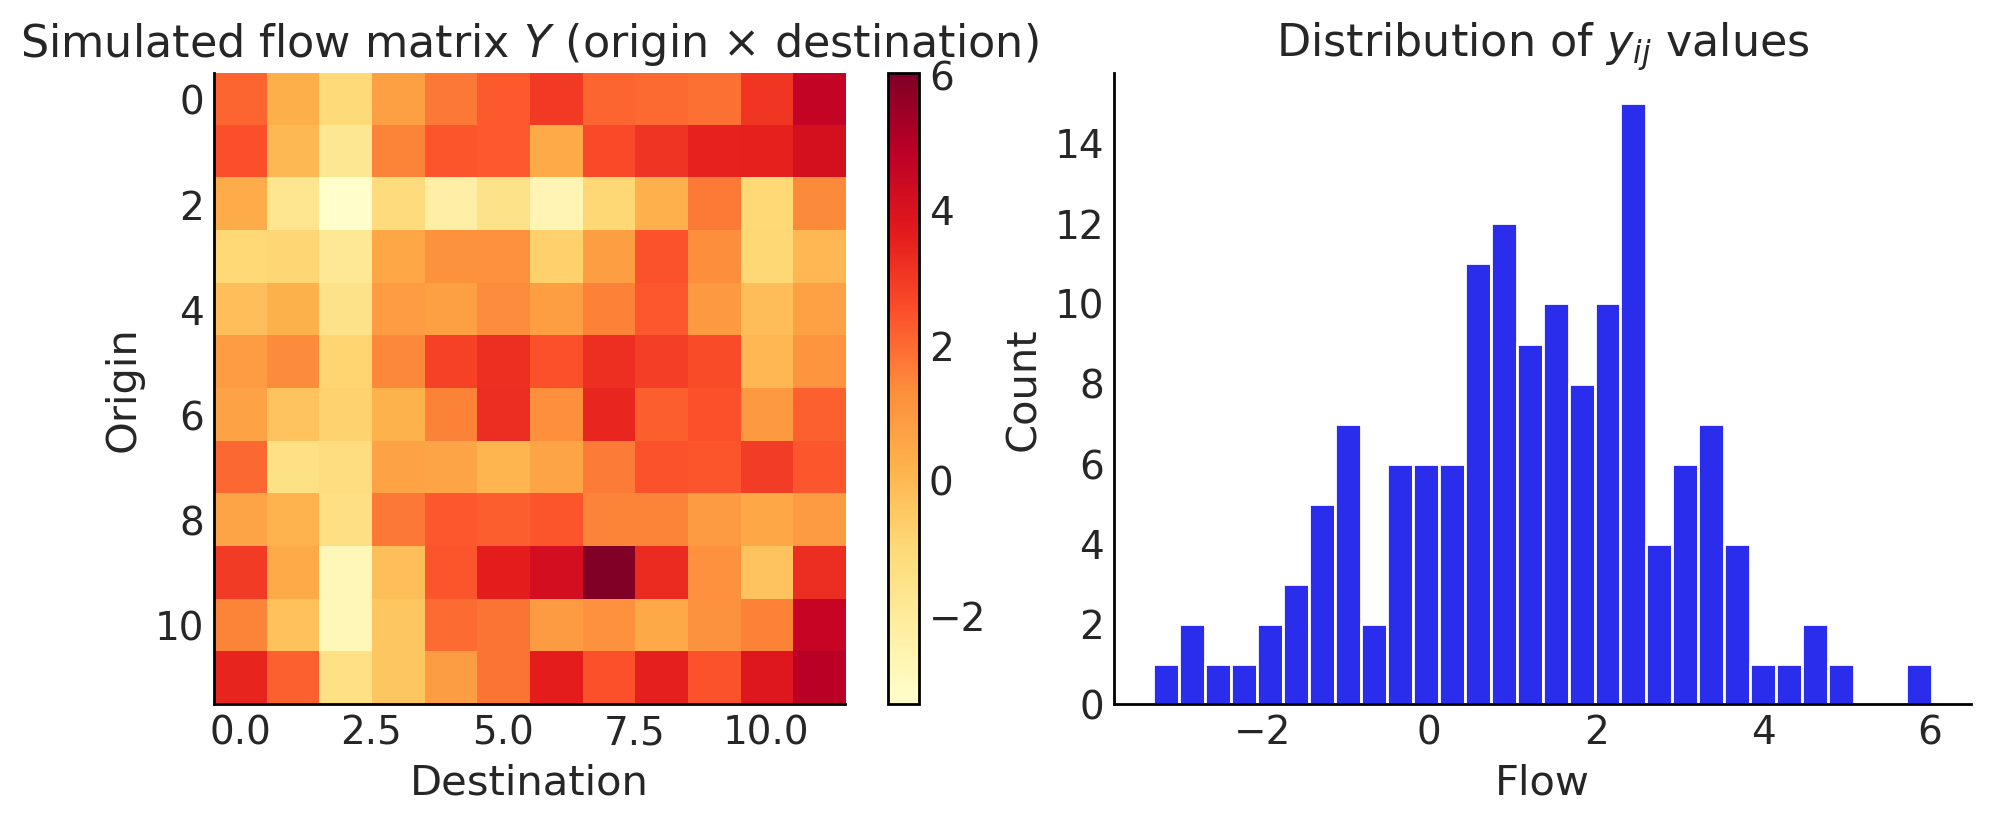

In [5]:
# Visualise the flow matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(y_vec.reshape(n, n), cmap="YlOrRd")
axes[0].set_title("Simulated flow matrix $Y$ (origin × destination)")
axes[0].set_xlabel("Destination")
axes[0].set_ylabel("Origin")
plt.colorbar(im, ax=axes[0])

axes[1].hist(y_vec, bins=30, edgecolor="white")
axes[1].set_title("Distribution of $y_{ij}$ values")
axes[1].set_xlabel("Flow")
axes[1].set_ylabel("Count")

#plt.tight_layout()
plt.show()

## 2  `SAR_Flow`: Three-parameter model

`SAR_Flow` places a Dirichlet prior on $(ρ_d, ρ_o, ρ_w)$ that enforces positivity and the stability constraint $\rho_d + \rho_o + \rho_w \leq 1$ exactly, using the stick-breaking transformation for NUTS efficiency.

The log-determinant $\log|A|$ is evaluated via the Barry–Pace trace-stochastic method, which requires only sparse matrix–vector products.

In [6]:
sar_flow = SAR_Flow(
    y_vec, G, X,
    col_names=col_names,
    logdet_method="traces",   # Barry-Pace stochastic trace (default)
    restrict_positive=True,   # Dirichlet stability prior
    miter=20,                 # trace polynomial order (increase for better accuracy)
    trace_seed=0,
)

idata_sar = sar_flow.fit(
    draws=1000, tune=1000, chains=4,
    target_accept=0.9, random_seed=42,
    progressbar=True,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho_simplex, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [7]:
# Posterior summary for the spatial autoregressive parameters
summary_rho = sar_flow.summary(var_names=["rho_d", "rho_o", "rho_w"])
print("=== SAR_Flow: spatial autoregressive parameters ===")
print(summary_rho.to_string())

# Compare to true values
print(f"\nTrue values:  rho_d={RHO_D}  rho_o={RHO_O}  rho_w={RHO_W}")

=== SAR_Flow: spatial autoregressive parameters ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
rho_d  0.452  0.065   0.332    0.579      0.001    0.001    3306.0    2851.0    1.0
rho_o  0.187  0.069   0.062    0.322      0.001    0.001    2284.0    1664.0    1.0
rho_w  0.079  0.061   0.000    0.188      0.001    0.001    1712.0    1134.0    1.0

True values:  rho_d=0.35  rho_o=0.25  rho_w=0.1


In [8]:
# Full coefficient summary
summary_beta = sar_flow.summary(var_names=["beta", "sigma"])
print("=== SAR_Flow: regression coefficients ===")
print(summary_beta.to_string())

=== SAR_Flow: regression coefficients ===
                        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[intercept]       -0.023  0.115  -0.228    0.203      0.002    0.002    2783.0    2984.0    1.0
beta[intra_indicator] -0.193  0.320  -0.787    0.419      0.006    0.005    2647.0    2835.0    1.0
beta[dest_x0]          0.953  0.138   0.692    1.218      0.003    0.002    2835.0    2680.0    1.0
beta[dest_x1]         -0.252  0.112  -0.463   -0.039      0.002    0.002    2869.0    2734.0    1.0
beta[orig_x0]          0.496  0.128   0.253    0.739      0.002    0.002    3107.0    2733.0    1.0
beta[orig_x1]          0.163  0.113  -0.064    0.358      0.002    0.002    2914.0    2616.0    1.0
beta[intra_x0]        -0.112  0.401  -0.833    0.663      0.008    0.006    2612.0    2740.0    1.0
beta[intra_x1]        -0.147  0.400  -0.906    0.571      0.008    0.006    2481.0    2868.0    1.0
sigma                  0.873  0.056   0.765    0.974      

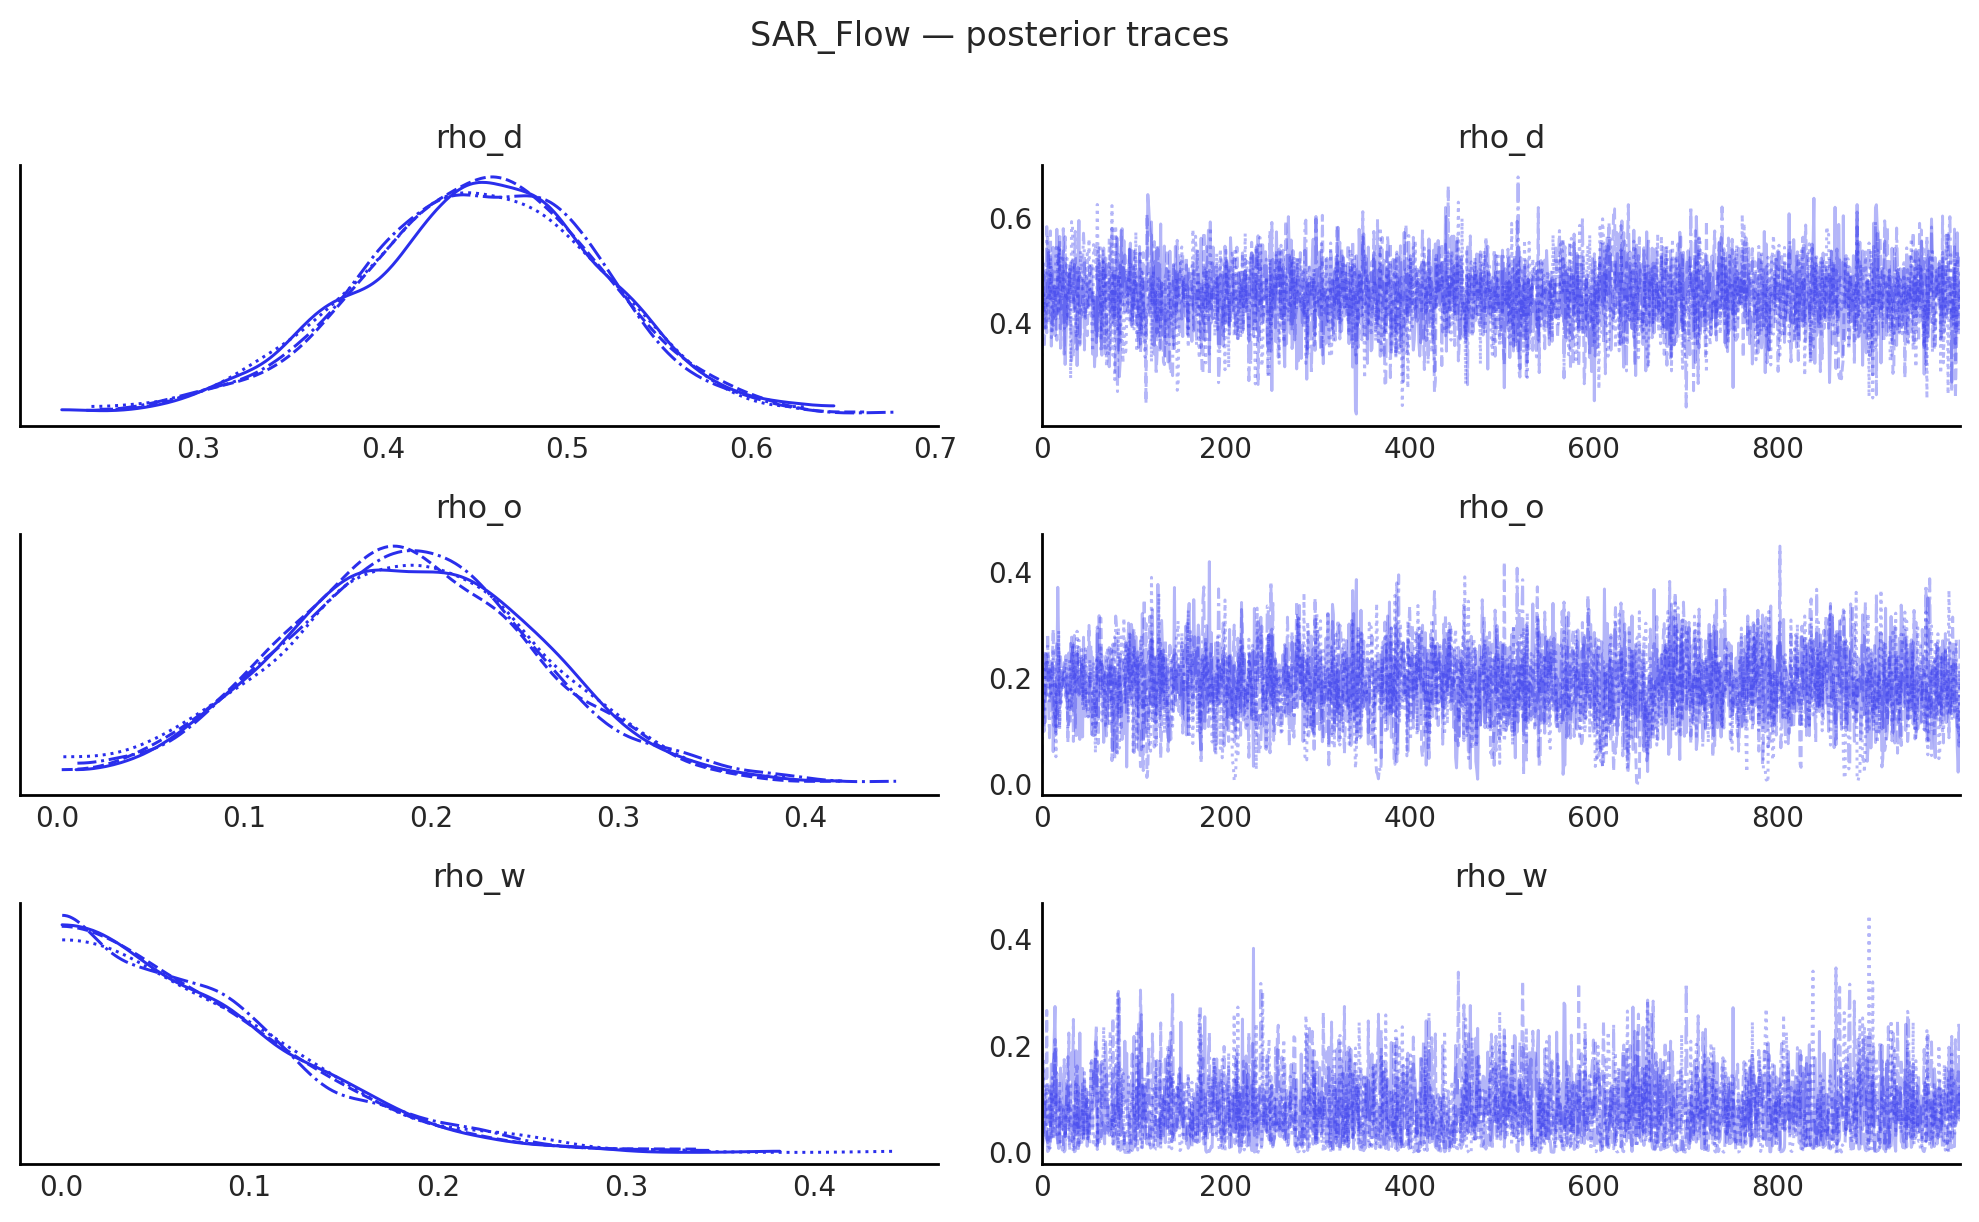

In [9]:
# Trace plots for the three ρ parameters
az.plot_trace(
    idata_sar,
    var_names=["rho_d", "rho_o", "rho_w"],
    figsize=(10, 6),
)
plt.suptitle("SAR_Flow — posterior traces", y=1.01)
plt.tight_layout()
plt.show()

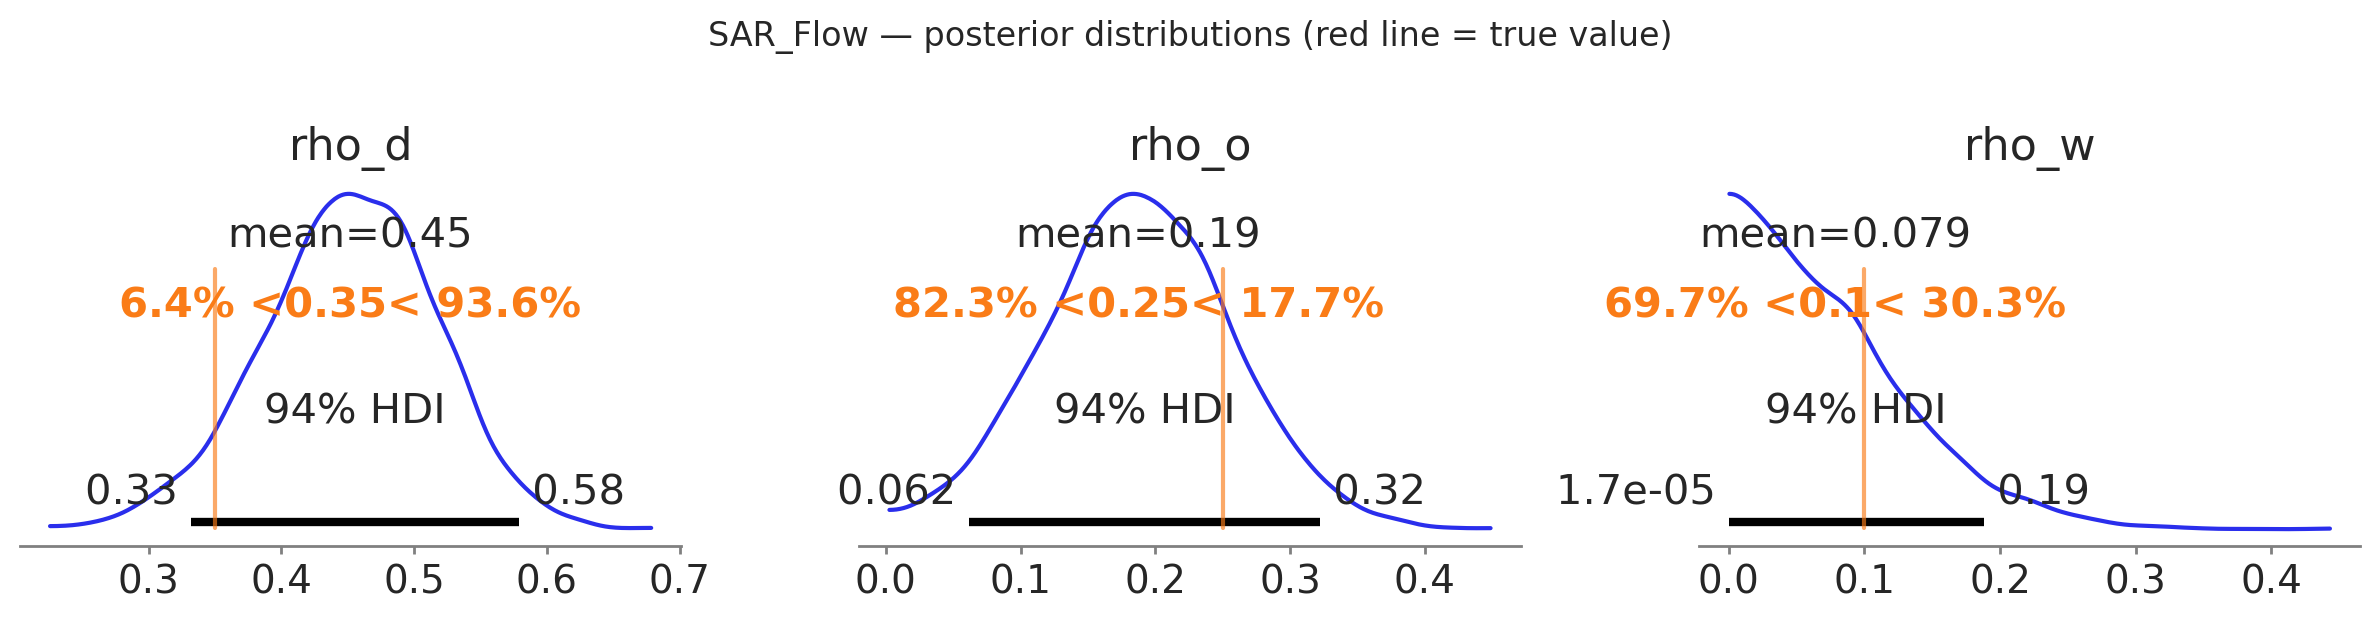

In [11]:
# Posterior densities with true-value markers
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
params = [("rho_d", RHO_D), ("rho_o", RHO_O), ("rho_w", RHO_W)]

for ax, (param, true_val) in zip(axes, params):
    az.plot_posterior(
        idata_sar,
        var_names=[param],
        ax=ax,
        ref_val=true_val,
        hdi_prob=0.94,
    )
    #ax.set_title(f"${param.replace('_', r'\\_')}$ (true = {true_val})")

plt.suptitle("SAR_Flow — posterior distributions (red line = true value)", y=1.02)
plt.tight_layout()
plt.show()

## 3  `SAR_Flow_Separable`: Constrained model

`SAR_Flow_Separable` imposes the constraint $\rho_w = -\rho_d \rho_o$, yielding:

* **Exact log-det** via eigenvalues of the small $n \times n$ matrix $W$ — no Monte Carlo traces needed.
* **Two free parameters** ($\rho_d$, $\rho_o$) instead of three.
* Typically **faster mixing** because the posterior geometry is simpler.

We generate new data that satisfies the constraint ($\rho_w = -\rho_d\rho_o = -0.12$) to give the model the best chance at recovery.

In [12]:
# True parameters for the separable model (asymmetric for identifiability)
RHO_D_SEP = 0.40
RHO_O_SEP = 0.30
RHO_W_SEP = -RHO_D_SEP * RHO_O_SEP   # = -0.12 (constraint)

print(f"Separable true values:  rho_d={RHO_D_SEP}  rho_o={RHO_O_SEP}"
      f"  rho_w=-rho_d*rho_o={RHO_W_SEP:.4f}")

data_sep = generate_flow_data_separable(
    n, G,
    rho_d=RHO_D_SEP, rho_o=RHO_O_SEP,
    beta_d=BETA_D, beta_o=BETA_O,
    sigma=SIGMA, seed=7,
)

y_sep   = data_sep["y_vec"]
X_sep   = data_sep["X"]
cn_sep  = data_sep["col_names"]

print(f"\ny_sep summary:  min={y_sep.min():.2f}  mean={y_sep.mean():.2f}  max={y_sep.max():.2f}")

Separable true values:  rho_d=0.4  rho_o=0.3  rho_w=-rho_d*rho_o=-0.1200

y_sep summary:  min=-7.03  mean=-2.31  max=2.36


In [13]:
sep_flow = SAR_Flow_Separable(
    y_sep, G, X_sep,
    col_names=cn_sep,
    # logdet_method="eigenvalue" is the default for SAR_Flow_Separable
    trace_seed=0,
)

idata_sep = sep_flow.fit(
    draws=1000, tune=1000, chains=4,
    target_accept=0.9, random_seed=42,
    progressbar=True,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho_d, rho_o, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [14]:
summary_sep = sep_flow.summary(var_names=["rho_d", "rho_o"])
print("=== SAR_Flow_Separable: spatial autoregressive parameters ===")
print(summary_sep.to_string())
print(f"\nTrue values:  rho_d={RHO_D_SEP}  rho_o={RHO_O_SEP}"
      f"  (rho_w = -rho_d*rho_o = {RHO_W_SEP:.4f} is derived)")

=== SAR_Flow_Separable: spatial autoregressive parameters ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
rho_d  0.239  0.078   0.090    0.379      0.001    0.001    4001.0    2979.0    1.0
rho_o  0.283  0.074   0.154    0.432      0.001    0.001    2804.0    2945.0    1.0

True values:  rho_d=0.4  rho_o=0.3  (rho_w = -rho_d*rho_o = -0.1200 is derived)


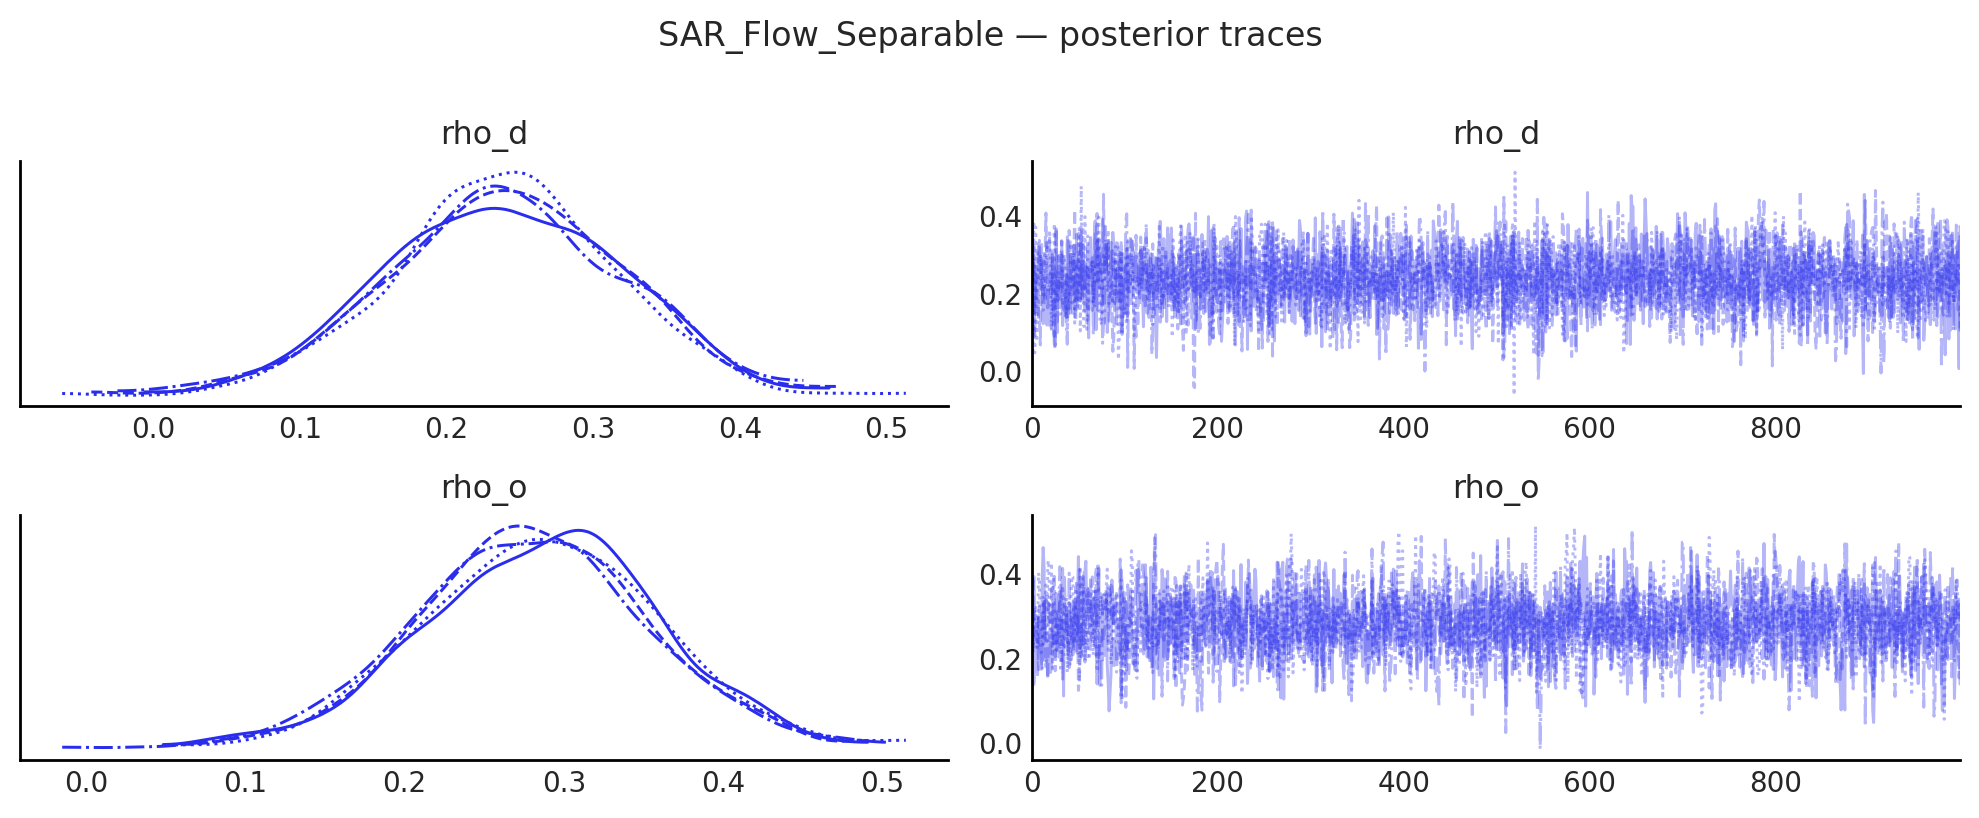

In [15]:
az.plot_trace(
    idata_sep,
    var_names=["rho_d", "rho_o"],
    figsize=(10, 4),
)
plt.suptitle("SAR_Flow_Separable — posterior traces", y=1.01)
plt.tight_layout()
plt.show()

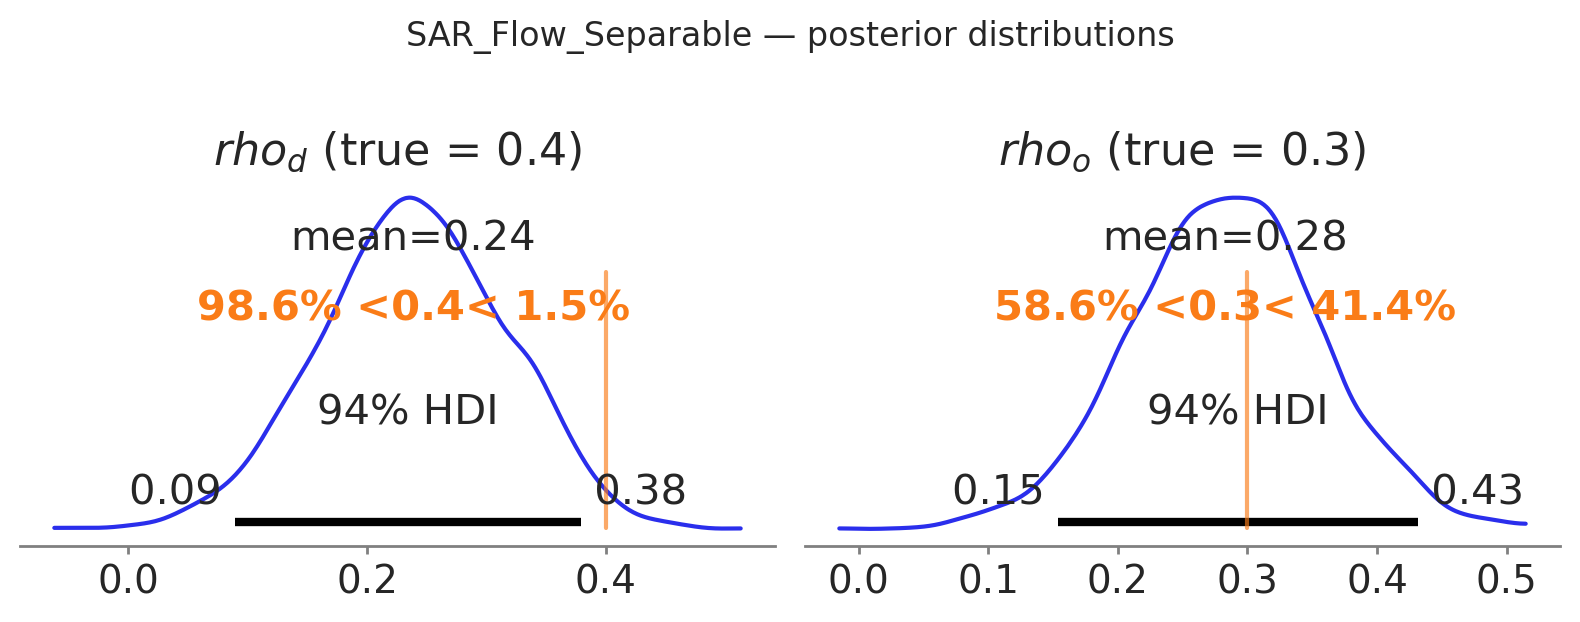

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, (param, true_val) in zip(axes, [("rho_d", RHO_D_SEP), ("rho_o", RHO_O_SEP)]):
    az.plot_posterior(idata_sep, var_names=[param], ax=ax, ref_val=true_val, hdi_prob=0.94)
    ax.set_title(f"${param.replace('_', r'_')}$ (true = {true_val})")

plt.suptitle("SAR_Flow_Separable — posterior distributions", y=1.02)
plt.tight_layout()
plt.show()

## 4  Design Matrix Details

The `flow_design_matrix` helper builds the standard LeSage O-D design matrix with destination, origin, and intra-zonal coefficient blocks.  Each column of the regional attribute matrix $X$ (shape $n \times k$) produces **three** columns in the full design matrix: one for destination effects, one for origin effects, and one for intra-zonal effects.

| Column group | Construction | Interpretation |
|---|---|---|
| intercept | $\mathbf{1}_N$ | global mean flow |
| intra_indicator | $\text{vec}(I_n)$ | intra-zonal dummy |
| dest_* | $\iota_n \otimes X$ | destination characteristics |
| orig_* | $X \otimes \iota_n$ | origin characteristics |
| intra_* | $\text{diag}(I_n) \cdot (I_n \otimes X)$ | intra-zonal attr. |

You can also pass a pre-built `pd.DataFrame` directly as `X` — column names are inferred automatically.

In [17]:
# Build a design matrix from scratch using regional attributes
X_regional = rng.standard_normal((n, 2))   # n × k attribute matrix
dm = flow_design_matrix(X_regional, col_names=["income", "pop"])

print(f"Regional attribute matrix: {X_regional.shape}  (n × k)")
print(f"Full O-D design matrix:    {dm.combined.shape}  (N × p)")
print(f"\nColumn names:\n  {dm.feature_names}")

pd.DataFrame(dm.combined[:6], columns=dm.feature_names).round(3)

Regional attribute matrix: (12, 2)  (n × k)
Full O-D design matrix:    (144, 8)  (N × p)

Column names:
  ['intercept', 'intra_indicator', 'dest_income', 'dest_pop', 'orig_income', 'orig_pop', 'intra_income', 'intra_pop']


,intercept,intra_indicator,dest_income,dest_pop,orig_income,orig_pop,intra_income,intra_pop
0,1.0,1.0,0.305,-1.040,0.305,-1.04,0.305,-1.04
1,1.0,0.0,0.750,0.941,0.305,-1.04,0.000,0.00
2,1.0,0.0,-1.951,-1.302,0.305,-1.04,-0.000,-0.00
3,1.0,0.0,0.128,-0.316,0.305,-1.04,0.000,-0.00
4,1.0,0.0,-0.017,-0.853,0.305,-1.04,-0.000,-0.00
5,1.0,0.0,0.879,0.778,0.305,-1.04,0.000,0.00


## 5  Spatial Effects

The flow SAR model has a rich effects decomposition.  For a one-unit shock to predictor $p$ in all regions, the total change in aggregate flows is:

$$
T_p = \iota_N' A^{-1} (\beta_d^{(p)} + \beta_o^{(p)}) \iota_N / N
$$

where $A = I_N - \rho_d W_d - \rho_o W_o - \rho_w W_w$.

`_compute_spatial_effects_posterior()` returns posterior draws of origin, destination, intra, network, and total effects for each predictor.  Below we summarise them as posterior means with 94% credible intervals.

In [18]:
effects = sar_flow._compute_spatial_effects_posterior(draws=500)

# k = number of regional predictors; col_names without intercept/intra blocks
k = sar_flow._k
pred_names = [c.replace("dest_", "") for c in col_names if c.startswith("dest_")]

rows = []
for effect_name, draws_arr in effects.items():
    for j, pred in enumerate(pred_names):
        col = draws_arr[:, j]
        rows.append({
            "effect": effect_name,
            "predictor": pred,
            "mean": col.mean(),
            "hdi_3%": np.percentile(col, 3),
            "hdi_97%": np.percentile(col, 97),
        })

effects_df = pd.DataFrame(rows)
print(effects_df.pivot(index="predictor", columns="effect", values="mean").round(4))

effect     destination   intra  network  origin   total
predictor                                              
x0              5.3205  0.4434  -5.7639  5.3205  5.3205
x1             -0.3245 -0.0270   0.3516 -0.3245 -0.3245


## 6  MCMC Diagnostics

Good practice after any Bayesian fit: check $\hat{R}$ (should be $< 1.01$) and effective sample size (ESS > 400 per chain).

In [19]:
for label, idata in [("SAR_Flow", idata_sar), ("SAR_Flow_Separable", idata_sep)]:
    diag = az.summary(idata, var_names=["rho_d", "rho_o"], stat_focus="mean")
    rhat_ok = (diag["r_hat"] < 1.01).all()
    ess_ok  = (diag["ess_bulk"] > 400).all()
    print(f"{label:25s}  r_hat<1.01: {rhat_ok}   ess_bulk>400: {ess_ok}")
    print(diag[["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]].to_string())
    print()

SAR_Flow                   r_hat<1.01: True   ess_bulk>400: True
        mean     sd  hdi_3%  hdi_97%  ess_bulk  r_hat
rho_d  0.452  0.065   0.332    0.579    3306.0    1.0
rho_o  0.187  0.069   0.062    0.322    2284.0    1.0

SAR_Flow_Separable         r_hat<1.01: True   ess_bulk>400: True
        mean     sd  hdi_3%  hdi_97%  ess_bulk  r_hat
rho_d  0.239  0.078   0.090    0.379    4001.0    1.0
rho_o  0.283  0.074   0.154    0.432    2804.0    1.0



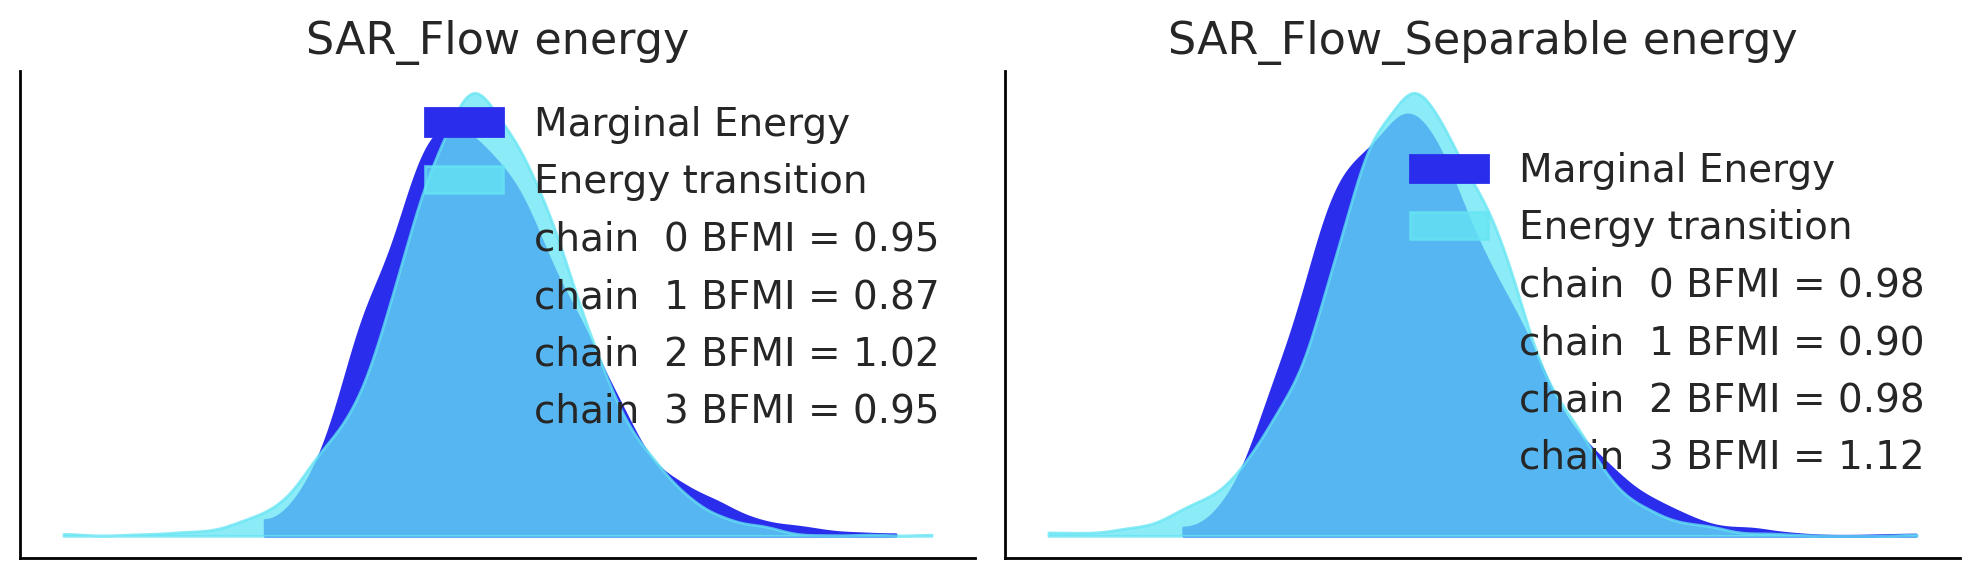

In [20]:
# Energy plot — checks that HMC is exploring the posterior efficiently
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
az.plot_energy(idata_sar, ax=axes[0])
axes[0].set_title("SAR_Flow energy")
az.plot_energy(idata_sep, ax=axes[1])
axes[1].set_title("SAR_Flow_Separable energy")
plt.tight_layout()
plt.show()

## 7  Model Comparison

The WAIC / LOO-CV scores can be used to compare `SAR_Flow` and `SAR_Flow_Separable` when both are estimated on the same data.  A lower ELPD (expected log pointwise predictive density) indicates a worse-fitting model.

> **Note**: here we fit `SAR_Flow` to the separable data to make the comparison meaningful — the separable model is nested in the unrestricted one.

In [21]:
# Fit unrestricted SAR_Flow on the same separable data for a fair comparison
sar_flow_on_sep = SAR_Flow(
    y_sep, G, X_sep,
    col_names=cn_sep,
    logdet_method="traces",
    miter=20,
    trace_seed=0,
)
idata_sar_on_sep = sar_flow_on_sep.fit(
    draws=1000, tune=1000, chains=4,
    target_accept=0.9, random_seed=42,
    progressbar=True,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho_simplex, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


In [22]:
# LOO-CV comparison (requires log-likelihood in idata; falls back to WAIC if unavailable)
try:
    loo_sar = az.loo(idata_sar_on_sep)
    loo_sep = az.loo(idata_sep)
    comparison = az.compare(
        {"SAR_Flow (3 ρ)": idata_sar_on_sep, "SAR_Flow_Separable": idata_sep}
    )
    print("LOO-CV model comparison:")
    print(comparison[["elpd_loo", "p_loo", "elpd_diff", "weight", "se", "warning"]].to_string())
except Exception as e:
    print(f"LOO not available (log-likelihood not stored): {e}")
    print("Tip: pass compute_log_likelihood=True to fit() to enable LOO/WAIC.")

LOO not available (log-likelihood not stored): log likelihood not found in inference data object
Tip: pass compute_log_likelihood=True to fit() to enable LOO/WAIC.


## 8  Prior Sensitivity and Stability Constraint

By default `SAR_Flow` uses a Dirichlet prior that forces $\rho_d, \rho_o, \rho_w \geq 0$ and $\rho_d + \rho_o + \rho_w \leq 1$.  Setting `restrict_positive=False` allows negative spillovers via independent `Uniform(-1, 1)` priors plus a differentiable stability wall potential.

Use `restrict_positive=False` when competitive effects (e.g. negative network parameter) are theoretically expected.

In [24]:
# Fit with restrict_positive=False to allow negative rho values
sar_flow_neg = SAR_Flow(
    y_vec, G, X,
    col_names=col_names,
    logdet_method="traces",
    restrict_positive=False,   # Uniform(-1,1) priors + stability potential
    miter=20, trace_seed=0,
)
idata_neg = sar_flow_neg.fit(
    draws=800, tune=1000, chains=4,
    target_accept=0.95, random_seed=42,
    progressbar=True,
)

summary_neg = sar_flow_neg.summary()
print("=== SAR_Flow (restrict_positive=False) ===")
print(summary_neg[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]].to_string())

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho_d, rho_o, rho_w, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 800 draw iterations (4_000 + 3_200 draws total) took 8 seconds.


=== SAR_Flow (restrict_positive=False) ===
                        mean     sd  hdi_3%  hdi_97%  r_hat
beta[intercept]        0.009  0.121  -0.212    0.242    1.0
beta[intra_indicator] -0.214  0.318  -0.843    0.352    1.0
beta[dest_x0]          0.909  0.144   0.639    1.173    1.0
beta[dest_x1]         -0.245  0.114  -0.443   -0.024    1.0
beta[orig_x0]          0.470  0.126   0.239    0.706    1.0
beta[orig_x1]          0.147  0.112  -0.069    0.351    1.0
beta[intra_x0]        -0.104  0.401  -0.858    0.656    1.0
beta[intra_x1]        -0.157  0.387  -0.846    0.605    1.0
rho_d                  0.480  0.066   0.361    0.603    1.0
rho_o                  0.232  0.078   0.084    0.373    1.0
rho_w                 -0.007  0.095  -0.175    0.171    1.0
sigma                  0.861  0.056   0.762    0.969    1.0


## 9  Quick Reference

```python
from bayespecon import SAR_Flow, SAR_Flow_Separable
from bayespecon import flow_design_matrix
from bayespecon.dgp.flows import generate_flow_data, generate_flow_data_separable

# Build design matrix from regional attributes
dm = flow_design_matrix(X_regional, col_names=["income", "pop"])

# --- SAR_Flow (three free ρ parameters) ---
model = SAR_Flow(
    y, G, dm.combined,
    col_names=dm.feature_names,
    logdet_method="traces",      # Barry-Pace stochastic traces (default)
    restrict_positive=True,      # Dirichlet stability prior
)
idata = model.fit(draws=2000, tune=1000, chains=4, random_seed=0)
model.summary(var_names=["rho_d", "rho_o", "rho_w"])

# --- SAR_Flow_Separable (ρ_w = -ρ_d·ρ_o, exact log-det) ---
sep_model = SAR_Flow_Separable(
    y, G, dm.combined,
    col_names=dm.feature_names,
    # logdet_method="eigenvalue" is the default
)
idata_sep = sep_model.fit(draws=2000, tune=1000, chains=4, random_seed=0)
```

### Key parameters

| Parameter | Default | Description |
|---|---|---|
| `logdet_method` | `"traces"` | `"traces"` (Barry–Pace) or `"eigenvalue"`/`"chebyshev"` for separable |
| `restrict_positive` | `True` | Dirichlet prior; set `False` for negative-spillover models |
| `miter` | 30 | Trace polynomial order (higher = more accurate, slower precomputation) |
| `trace_riter` | 50 | Monte Carlo probes for trace estimation |

### Model choice guide

| Data characteristic | Recommended model |
|---|---|
| No prior on sign of spatial effects | `SAR_Flow(restrict_positive=False)` |
| Positive spillovers expected | `SAR_Flow(restrict_positive=True)` |
| Separability plausible, fast inference needed | `SAR_Flow_Separable` |
| Count/non-negative flows | `PoissonFlow` or `PoissonFlow_Separable` |